In [152]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(lme4)
  library(broom.mixed)
  library(ggplot2)
library(dplyr)
library(tidyr)
library(tibble)
#library(ggridges)
    library(stringr)
library(tidyverse)
library(lmerTest)
library(broom.mixed)
library(ComplexHeatmap)
library(circlize)

})


In [153]:
#work dir
setwd("/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/")

In [154]:
##LOAD CLINICAL DATA######
cov <- read.table("/home/mjehangir/telomere-sv-analysis/data/clinical_data.txt",
                           sep = "\t",
                           header = TRUE,
                           check.names = FALSE)
head(cov)


,ID,Age,Grade,CDKN2A/B,TP53,ATRX,onco_Alterations,ONT_Alterations
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2436A,NA,3,NA,NA,NA,5,40
2,3188,NA,3,NA,NA,NA,16,107
3,3988,0,2,2,0,0,17,105
4,6265D,33,3,1,0,0,42,87
5,6266D,40,2,1,0,0,28,105
6,6269C,23,3,2,0,0,14,214


In [155]:
####### SV AND CNV DATA#########
all_df <- read.table("mixed_model_SVs_CNV_TL_with_SV_final.tsv",
# all_df <- read.table("../mixed_model_SVs_CNV_TL_with_SV_final_feb_24.tsv",
                     sep = "\t", header = TRUE,
                           check.names = FALSE)

In [156]:
####### HARS DATA#########
all_HARs <- read.table("/home/mjehangir/telomere-sv-analysis/data/TEL_merged_HARs_with_chr-arms.txt",
                           sep = "\t",
                           header = TRUE,
                           check.names = FALSE)
head(all_HARs)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,⋯,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<lgl>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,⋯,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,NA
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,⋯,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,NA
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,200151,3002265,12,-0.4724,2802114,Loss,-0.1005,0.70497630,NA
4,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,3202416,46034730,207,-0.3523,42832314,Loss,-0.1005,0.70497630,NA
5,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,46234881,54641223,43,-0.2802,8406342,Loss,-0.1005,0.70497630,NA
6,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,1,54841374,68051340,67,-0.2241,13209966,Loss,-0.1005,0.70497630,NA


In [157]:
####### ecDNA FROM DECOIL#########

ecdna <- read.table("/home/mjehangir/telomere-sv-analysis/data/ecDNA_with_tel.bed",
                           sep = "\t",
                           header = TRUE,
                           check.names = FALSE)
head(ecdna)

,sample,Chromosome,Arm,chr_arm,start,end,TL_kb,norm_TL,ArmLen,estimated_proportions,fragment_id,circ_id
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<chr>,<int>
1,2436A,chr1,q,chr1q,196089010,196200712,5.051167,-0.2134030,124339061,108,989.993,1
2,2436A,chr1,q,chr1q,196202843,196213045,5.051167,-0.2134030,124339061,108,1001,1
3,2436A,chr14,q,chr14q,100384316,100903138,3.490600,-1.5358237,89761231,72,12905,25
4,2436A,chr6,q,chr6q,132892661,132908593,5.896929,0.5032938,112454080,58,6365,18
5,2436A,chr7,q,chr7q,145478082,145544265,6.483083,1.0000000,98502993,58,7405.7413.7417,18
6,2436A,chr7,q,chr7q,145467433,145478082,6.483083,1.0000000,98502993,58,7401,18


In [158]:
####### ARM LEVEL ANEUPLOIDY #########

aneuploidy <- read.table("/tgen_labs/barthel/projects/Jenkins_Mayo/aneuploidy/Glioma_v2_CNV_stats.txt",
                           sep = "\t",
                           header = TRUE,
                           check.names = FALSE)
head(aneuploidy)

,SampleID,seqnames,arm,arm_call,arm_num_seg,arm_cr_wmean,arm_cr_wsd
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,6478A,chr4,4p,0,2,1.0508593,278.6570
2,6298B,chr4,4p,0,2,0.9986684,163.3790
3,6483C,chr4,4p,0,4,1.0274257,153.1851
4,6266D,chr4,4p,0,4,1.0363533,198.2503
5,2436A,chr21,21p,0,NA,NA,NA
6,6414C,chr21,21p,0,NA,NA,NA


In [159]:
# Simple frequency count
table(aneuploidy$arm_call)

# If you want to see it as a percentage
prop.table(table(aneuploidy$arm_call)) * 100


 -1   0   1 
 30 577  32 


       -1         0         1 
 4.694836 90.297340  5.007825 

In [160]:
head(all_df)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,sv_rate_BND,sv_rate_INS,sv_rate_INV,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_BND,sv_proportion_INS,sv_proportion_INV
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,2436A,chr1p,5.221000,-0.06948662,NA,NA,NA,NA,0.000000000,0.01612276,0.008061378,0.032245513,0,0.000000e+00,0.0002582543,0.0000000,0,0
2,2436A,chr1q,5.051167,-0.21340301,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,0.016085050,0.000000000,0,2.126283e-04,0.0000000000,0.0000000,0,0
3,3188,chr1p,1.642500,-2.95775970,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,0.386946155,0.008061378,0,8.025102e-05,0.0000000000,0.0000000,0,0
4,3188,chr1q,3.086500,0.65675845,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,0.313658473,0.000000000,0,4.447516e-06,0.0000000000,0.0000000,0,0
5,3988,chr1p,2.347500,-2.53325753,NA,NA,NA,NA,0.000000000,0.00000000,0.330516508,0.016122756,0,0.000000e+00,0.0000000000,0.0000000,0,0
6,3988,chr1q,5.083000,-0.45973091,NA,NA,NA,NA,0.000000000,0.00000000,0.490594022,0.000000000,0,0.000000e+00,0.0000000000,0.5437668,0,0


In [161]:
colnames(all_df)

[1] "Sample_ID"                  "chr_arm"                   
 [3] "final_average_TL_p75_kb"    "norm_TL"                   
 [5] "cnv_rate_per_mb_Gain"       "cnv_rate_per_mb_Loss"      
 [7] "cnv_proportion_per_mb_Gain" "cnv_proportion_per_mb_Loss"
 [9] "sv_rate_DEL"                "sv_rate_DUP"               
[11] "sv_rate_BND"                "sv_rate_INS"               
[13] "sv_rate_INV"                "sv_proportion_DEL"         
[15] "sv_proportion_DUP"          "sv_proportion_BND"         
[17] "sv_proportion_INS"          "sv_proportion_INV"

In [162]:
##### sanity check of data########
# To see the unique sample IDs
unique(all_df$Sample_ID)

# To count how many unique samples there are
length(unique(all_df$Sample_ID))

[1] "2436A" "3188"  "3988"  "6265D" "6266D" "6269C" "6277A" "6285B" "6298B"
[10] "6314E" "6324B" "6365A" "6414C" "6423A" "6436B" "6439C" "6478A" "6483C"
[19] "6500D" "6605D"

[1] 20

In [163]:
######Merge aneuploidy with all df datset########


# 1. FIX THE ANEUPLOIDY FILE
aneup_prepared <- aneuploidy %>%
  mutate(
    # Clean Sample ID 
    SampleID = trimws(as.character(SampleID)),
    
    # Fix the key (extract 'p' or 'q' to avoid 'chr11p')
    arm_letter = str_extract(arm, "[pq]"),
    chr_arm = paste0(seqnames, arm_letter) # Name it exactly 'chr_arm'
  ) %>%
  # Select only the key and the data
  dplyr::select(SampleID, chr_arm, aneuploidy = arm_call) %>%
  distinct()

# 2. FIX THE MAIN DATAFRAME
all_df <- all_df %>%
  # Remove any previous failed aneuploidy columns (.x, .y, or NA columns)
  dplyr::select(-matches("aneuploidy")) %>%
  mutate(
    Sample_ID = trimws(as.character(Sample_ID)),
    chr_arm = trimws(as.character(chr_arm))
  )

# 3. THE FINAL MERGE
# We match Sample_ID to SampleID, and chr_arm to chr_arm
all_df <- all_df %>%
  left_join(aneup_prepared, 
            by = c("Sample_ID" = "SampleID", "chr_arm" = "chr_arm"))

# 4. THE TRUTH TEST
print("Distribution after fixing keys:")
table(all_df$aneuploidy, useNA = "always")

[1] "Distribution after fixing keys:"



  -1    0    1 <NA> 
  29  551   31  220 

In [164]:
# --- 1. Replace any NA by zero because that arm has zero instability ---
all_df <- all_df %>%
  # Replace NA with 0 ONLY for instability metrics (CNV and SV)
  mutate(across(
    .cols = contains("cnv_") | contains("sv_"), 
    .fns = ~replace_na(., 0)
  )) %>%
  # Create Z-score for Telomere Length
  mutate(TL_zscore = as.numeric(scale(final_average_TL_p75_kb)))

head(all_df)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,sv_rate_BND,sv_rate_INS,sv_rate_INV,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_BND,sv_proportion_INS,sv_proportion_INV,aneuploidy,TL_zscore
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>
1,2436A,chr1p,5.221000,-0.06948662,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,0.008061378,0.032245513,0,0.000000e+00,0.0002582543,0.0000000,0,0,0,0.08954062
2,2436A,chr1q,5.051167,-0.21340301,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,0.016085050,0.000000000,0,2.126283e-04,0.0000000000,0.0000000,0,0,0,0.00105274
3,3188,chr1p,1.642500,-2.95775970,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,0.386946155,0.008061378,0,8.025102e-05,0.0000000000,0.0000000,0,0,-1,-1.77495711
4,3188,chr1q,3.086500,0.65675845,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,0.313658473,0.000000000,0,4.447516e-06,0.0000000000,0.0000000,0,0,0,-1.02259307
5,3988,chr1p,2.347500,-2.53325753,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,0.330516508,0.016122756,0,0.000000e+00,0.0000000000,0.0000000,0,0,0,-1.40763256
6,3988,chr1q,5.083000,-0.45973091,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,0.490594022,0.000000000,0,0.000000e+00,0.0000000000,0.5437668,0,0,0,0.01763879


In [165]:
all_df <- all_df %>%
  mutate(
    is_loss = ifelse(aneuploidy == -1, 1, 0),
    is_gain = ifelse(aneuploidy == 1, 1, 0)
  )
head(all_df)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,sv_rate_INV,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_BND,sv_proportion_INS,sv_proportion_INV,aneuploidy,TL_zscore,is_loss,is_gain
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5.221000,-0.06948662,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,0,0.000000e+00,0.0002582543,0.0000000,0,0,0,0.08954062,0,0
2,2436A,chr1q,5.051167,-0.21340301,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,0,2.126283e-04,0.0000000000,0.0000000,0,0,0,0.00105274,0,0
3,3188,chr1p,1.642500,-2.95775970,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,0,8.025102e-05,0.0000000000,0.0000000,0,0,-1,-1.77495711,1,0
4,3188,chr1q,3.086500,0.65675845,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,0,4.447516e-06,0.0000000000,0.0000000,0,0,0,-1.02259307,0,0
5,3988,chr1p,2.347500,-2.53325753,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0.000000e+00,0.0000000000,0.0000000,0,0,0,-1.40763256,0,0
6,3988,chr1q,5.083000,-0.45973091,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0.000000e+00,0.0000000000,0.5437668,0,0,0,0.01763879,0,0


In [166]:
#####Make all the datasets clean and same column names for merge with all df######
# -------------------------
# 0) Read covariates (ID, Age, ...)
# -------------------------
cov <- cov %>%
  dplyr::rename(Sample_ID = ID) %>%
  mutate(Age = as.numeric(Age)) %>%
  dplyr::select(Sample_ID, Age)

# -------------------------
# 1) ecDNA: sum(estimated_proportions) per Sample_ID x chr_arm
# -------------------------
ecdna_arm <- ecdna %>%
  mutate(
    Sample_ID = trimws(sample),
    chr_arm   = trimws(chr_arm)
  ) %>%
  group_by(Sample_ID, chr_arm) %>%
  summarise(
    ecDNA_estprop_sum = sum(estimated_proportions, na.rm = TRUE),
    .groups = "drop"
  )

# -------------------------
# 2) HARs: count ecDNA_flag=="ecDNA" per Sample_ID x chr_arm
# -------------------------
har_arm <- all_HARs %>%
  mutate(
    Sample_ID = trimws(Sample_prefix),
    chr_arm   = trimws(chr_arm)
  ) %>%
  group_by(Sample_ID, chr_arm) %>%
  summarise(
    HAR_ecDNA_count = sum(ecDNA_flag == "ecDNA", na.rm = TRUE),
    .groups = "drop"
  )

# -------------------------
# 3) Merge into all_df + add Age + fill missing ecDNA/HAR with 0
# -------------------------
all_df_aug <- all_df %>%
  left_join(ecdna_arm, by = c("Sample_ID", "chr_arm")) %>%
  left_join(har_arm,   by = c("Sample_ID", "chr_arm")) %>%
  left_join(cov,       by = "Sample_ID") %>%
  mutate(
    ecDNA_estprop_sum = replace_na(ecDNA_estprop_sum, 0),
    HAR_ecDNA_count   = replace_na(HAR_ecDNA_count, 0)
  )


In [167]:
# 1. Clean the ecDNA counts before merging
ecdna_counts_clean <- ecdna %>%
  mutate(
    Sample_ID = trimws(as.character(sample)), # Ensure IDs are clean
    chr_arm = trimws(as.character(chr_arm))
  ) %>%
  group_by(Sample_ID, chr_arm) %>%
  summarise(
    has_ecdna = 1,
    ecdna_max_amp = max(estimated_proportions, na.rm = TRUE),
    num_circuits = n_distinct(circ_id),
    .groups = "drop" # This fixes the grouping warning
  )

# 2. Re-merge carefully
all_df_aug <- all_df_aug %>%
  # Remove the failed column if it somehow exists partially
  dplyr::select(-any_of(c("has_ecdna", "ecdna_max_amp", "num_circuits"))) %>%
  left_join(ecdna_counts_clean, by = c("Sample_ID", "chr_arm")) %>%
  # Replace NAs with 0 only for the logic columns
  mutate(
    has_ecdna = ifelse(is.na(has_ecdna), 0, has_ecdna),
    num_circuits = ifelse(is.na(num_circuits), 0, num_circuits)
  )

# 3. Check if it worked
table(all_df_aug$has_ecdna)


  0   1 
788  43 

In [168]:
head(all_df_aug, 2)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,aneuploidy,TL_zscore,is_loss,is_gain,ecDNA_estprop_sum,HAR_ecDNA_count,Age,has_ecdna,ecdna_max_amp,num_circuits
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>
1,2436A,chr1p,5.221000,-0.06948662,0.000000000,0,0.000000000,0,0.000000000,0.01612276,⋯,0,0.08954062,0,0,0,0,NA,0,NA,0
2,2436A,chr1q,5.051167,-0.21340301,0.008042525,0,0.001609727,0,0.008042525,0.00000000,⋯,0,0.00105274,0,0,216,0,NA,1,108,1


In [169]:
all_df_aug = all_df_aug %>% rename(aneu_loss = is_loss,
                     aneu_gain = is_gain)

In [170]:
#write.table(all_df_aug, file = "/home/mjehangir/telomere-sv-analysis_backup/data/all_df_aug_correlation.tsv", 
            sep = "\t", 
            row.names = FALSE, 
            quote = FALSE)

ERROR: Error in parse(text = input): <text>:2:23: unexpected ','
1: #write.table(all_df_aug, file = "/home/mjehangir/telomere-sv-analysis_backup/data/all_df_aug_correlation.tsv", 
2:             sep = "\t",
                         ^


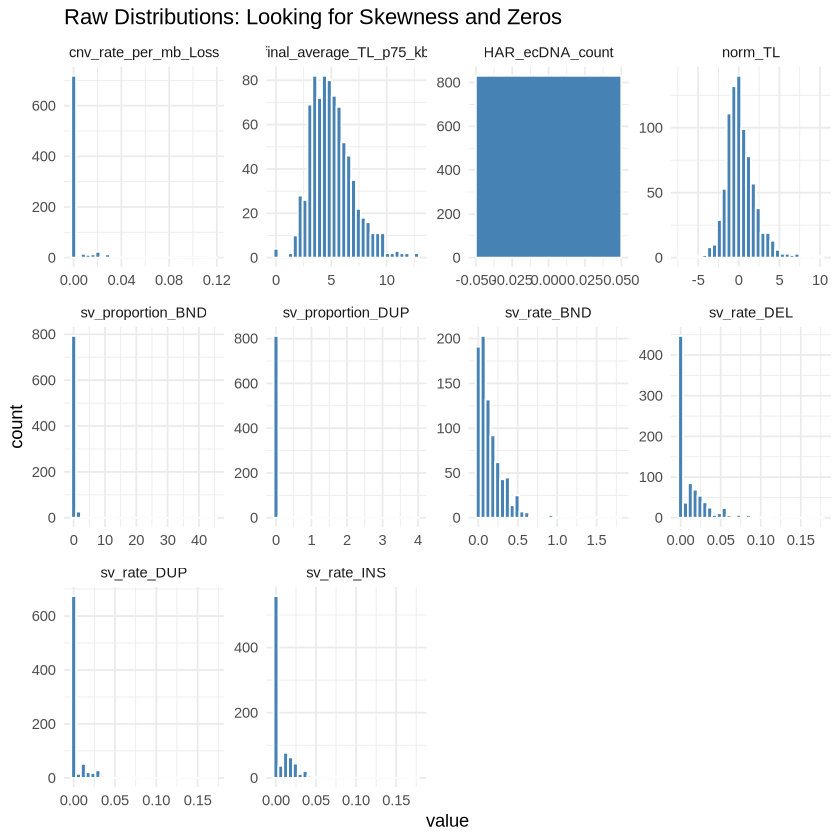

In [171]:

# We pick representative variables for the overview of its distribution
vars_to_plot <- c("final_average_TL_p75_kb","norm_TL","sv_rate_INS","sv_rate_DUP","sv_proportion_DUP","sv_proportion_BND", "sv_rate_DEL","sv_rate_BND", "cnv_rate_per_mb_Loss", "HAR_ecDNA_count")

all_df_aug %>%
  dplyr::select(all_of(vars_to_plot)) %>%
  pivot_longer(everything()) %>%
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  facet_wrap(~name, scales = "free") +
  theme_minimal() +
  labs(title = "Raw Distributions: Looking for Skewness and Zeros")

In [172]:
#####Normalized the SV and CNV rate and proportions
# 1. Define the variables to transform
all_vars <- c("sv_rate_BND", "sv_rate_DEL", "sv_rate_DUP", "sv_rate_INS", "sv_rate_INV",
              "cnv_rate_per_mb_Loss", "cnv_rate_per_mb_Gain", 
              "sv_proportion_BND", "sv_proportion_DEL")

# 2. Apply log10 transformation with an offset
# We create new columns with the suffix '_log'
#a log transform with a minimum pseudocount/2 so zeros don’t become -Inf

all_df_aug <- all_df_aug %>%
  dplyr::mutate(across(all_of(all_vars), 
                ~ log10(.x + (min(.x[.x > 0], na.rm = TRUE) / 2)), 
                .names = "{.col}_log"))


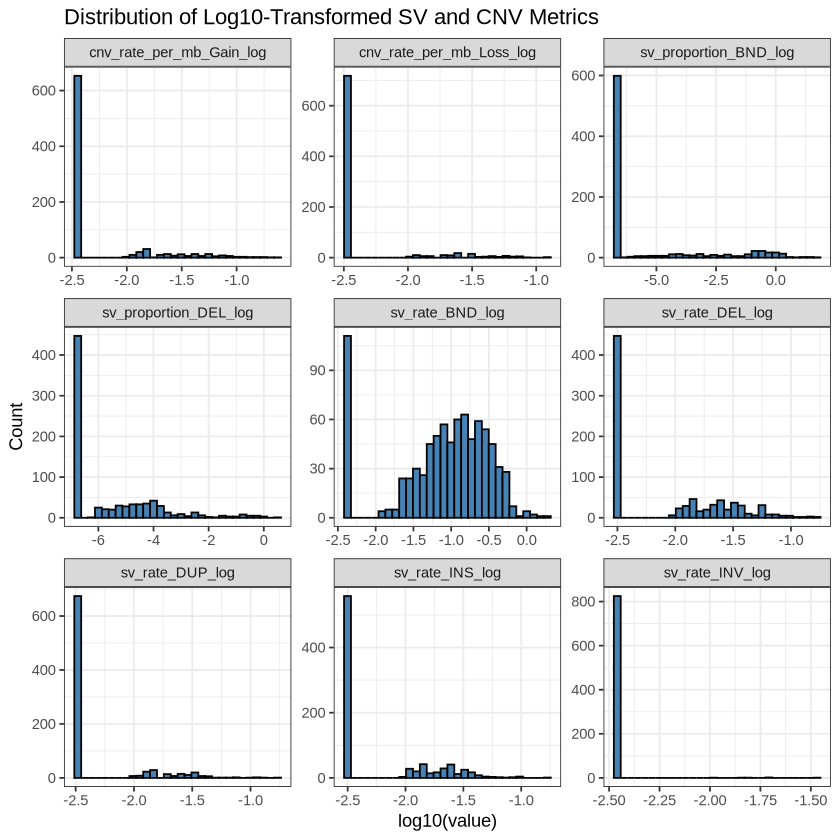

In [121]:
# Select log-transformed columns and reshape to long format
log_long <- all_df_aug %>%
  dplyr::select(contains("_log")) %>%
  pivot_longer(
    cols = everything(),
    names_to = "variable",
    values_to = "value"
  )

# Plot histograms
ggplot(log_long, aes(x = value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "black") +
  facet_wrap(~ variable, scales = "free") +
  theme_bw() +
  labs(
    title = "Distribution of Log10-Transformed SV and CNV Metrics",
    x = "log10(value)",
    y = "Count"
  )


In [122]:
head(all_df_aug)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,num_circuits,sv_rate_BND_log,sv_rate_DEL_log,sv_rate_DUP_log,sv_rate_INS_log,sv_rate_INV_log,cnv_rate_per_mb_Loss_log,cnv_rate_per_mb_Gain_log,sv_proportion_BND_log,sv_proportion_DEL_log
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5.221000,-0.06948662,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,0,-1.9174994,-2.474780,-1.710542,-1.448588,-2.47478,-2.474780,-2.474780,-6.7196807,-6.638746
2,2436A,chr1q,5.051167,-0.21340301,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,1,-1.6964640,-1.943328,-2.474780,-2.474780,-2.47478,-2.474780,-1.943328,-6.7196807,-3.671910
3,3188,chr1p,1.642500,-2.95775970,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,0,-0.4078490,-1.448588,-2.474780,-1.942610,-2.47478,-1.710542,-2.474780,-6.7196807,-4.094308
4,3188,chr1q,3.086500,0.65675845,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,1,-0.4979976,-1.943328,-2.474780,-2.474780,-2.47478,-2.474780,-1.943328,-6.7196807,-5.330008
5,3988,chr1p,2.347500,-2.53325753,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,-0.4755426,-2.474780,-2.474780,-1.710542,-2.47478,-2.474780,-2.474780,-6.7196807,-6.638746
6,3988,chr1q,5.083000,-0.45973091,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,-0.3057242,-2.474780,-2.474780,-2.474780,-2.47478,-2.474780,-2.474780,-0.2645872,-6.638746


In [123]:
### Standardize raw telomere data into Z-scores to identify outliers and correct for scale variance across the dataset.
all_df_aug <- all_df_aug %>%
  mutate(
    # 1. Absolute TL (should already be there)
    final_average_TL_p75_kb = as.numeric(as.character(final_average_TL_p75_kb)),
    
    # 2. Z-score TL
    TL_zscore = as.numeric(scale(final_average_TL_p75_kb)),
    
    # 3. Normalized TL (if not already defined, usually 0 to 1 scale)
    norm_TL = (final_average_TL_p75_kb - min(final_average_TL_p75_kb, na.rm=T)) / 
              (max(final_average_TL_p75_kb, na.rm=T) - min(final_average_TL_p75_kb, na.rm=T))
  )

In [124]:
# --- 1. EXTRACT CHROMOSOME ARM METADATA from edDNA file ---
# Isolate unique arm lengths from the ecDNA table to use as a normalization baseline
arm_lengths <- ecdna %>%
  dplyr::mutate(
    Sample_ID = trimws(sample), 
    chr_arm   = trimws(chr_arm)
  ) %>%
  dplyr::group_by(Sample_ID, chr_arm) %>%
  # Use the first occurrence of ArmLen; convert from bases to Megabases (Mb)
  dplyr::summarise(arm_size_mb = first(ArmLen) / 1e6, .groups = "drop")

# --- 2. INTEGRATE WITH MAIN DATASET ---
# Join the arm size metadata into the augmented dataframe for rate calculations
all_df_aug <- all_df_aug %>%
  dplyr::left_join(arm_lengths, by = c("Sample_ID", "chr_arm"))

# --- 3. CALCULATE NORMALIZED HAR METRICS ---
# Define the density and distribution of Highly Amplified Regions (HARs)
all_df_aug <- all_df_aug %>%
  dplyr::mutate(
    # HAR Density: Count normalized by arm size. 
    # '+ 0.001' prevents Division by Zero errors for missing/tiny arm data.
    HAR_rate_per_Mb = HAR_ecDNA_count / (arm_size_mb + 0.001), 
    
    # HAR Distribution: Binary indicator (Presence/Absence) for categorical analysis
    HAR_Distribution = ifelse(HAR_ecDNA_count > 0, 1, 0)
  )

In [125]:
out_dir <- "/home/mjehangir/telomere-sv-analysis/data/"
if(!dir.exists(out_dir)) dir.create(out_dir)

# 1. Save as a Tab-Separated File (Best for large genomic tables)
write.table(all_df_aug, 
            file = paste0(out_dir, "all_df_aug_final_2026.txt"), 
            sep = "\t", 
            row.names = FALSE, 
            quote = FALSE)